# Business case:
The objective of this project is to build a machine learning model to predict whether a customer will purchase an insurance product.

Business Goals:
- Identify potential customers
- Improve marketing efficiency
- Increase conversion rate

## Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score, confusion_matrix, roc_auc_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Load dataset

In [3]:
df = pd.read_csv("train.csv")
df

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595207,1488013,0,3,1,10,0,0,0,0,0,...,4,1,9,6,0,1,1,0,1,1
595208,1488016,0,5,1,3,0,0,0,0,0,...,4,1,3,8,1,0,1,0,1,1
595209,1488017,0,1,1,10,0,0,1,0,0,...,3,2,2,6,0,0,1,0,0,0
595210,1488021,0,5,2,3,1,0,0,0,1,...,4,1,4,2,0,1,1,1,0,0


# Basic Check

In [4]:
df.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [5]:
df.tail()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
595207,1488013,0,3,1,10,0,0,0,0,0,...,4,1,9,6,0,1,1,0,1,1
595208,1488016,0,5,1,3,0,0,0,0,0,...,4,1,3,8,1,0,1,0,1,1
595209,1488017,0,1,1,10,0,0,1,0,0,...,3,2,2,6,0,0,1,0,0,0
595210,1488021,0,5,2,3,1,0,0,0,1,...,4,1,4,2,0,1,1,1,0,0
595211,1488027,0,0,1,8,0,0,1,0,0,...,4,4,3,8,0,1,0,0,0,0


In [6]:
df.sample(5)

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
85876,214810,0,1,2,3,1,0,0,1,0,...,5,1,3,9,0,0,1,0,0,0
162017,405002,0,0,1,7,0,0,1,0,0,...,8,3,1,5,0,1,1,1,1,0
109275,273544,0,5,2,3,0,0,0,0,0,...,8,2,6,9,0,1,1,0,1,0
428732,1071510,0,2,1,2,1,0,0,1,0,...,5,2,5,14,0,1,0,1,0,0
34027,85356,0,5,4,6,1,0,0,0,0,...,4,0,2,2,0,0,0,0,1,0


In [7]:
df.shape

(595212, 59)

The dataset contains 595,212 rows and 59 features.

In [8]:
df.ndim

2

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

Both numerical and potential categorical variables are present.

In [10]:
df.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.115549e+06,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.488027e+06,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Distribution of Feature types

In [11]:
df.dtypes.value_counts()

int64      49
float64    10
Name: count, dtype: int64

Observations:
- Majority of the features are numerical
- Numerical dominance supports the use of scaling and advanced ML algorithms

In [12]:
df.isnull().sum()

id                0
target            0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0


There is no missing value

In [13]:
df.duplicated().sum()

np.int64(0)

there is no duplicate data

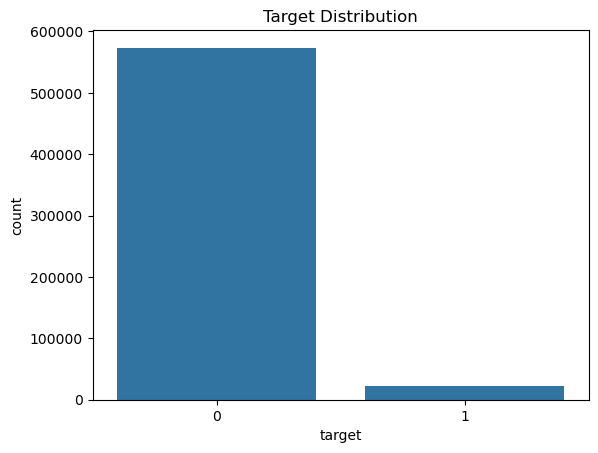

In [14]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

Observation:
- Dataset is highly imbalanced (~96% vs ~4%)

### Numeric Feature Distribution

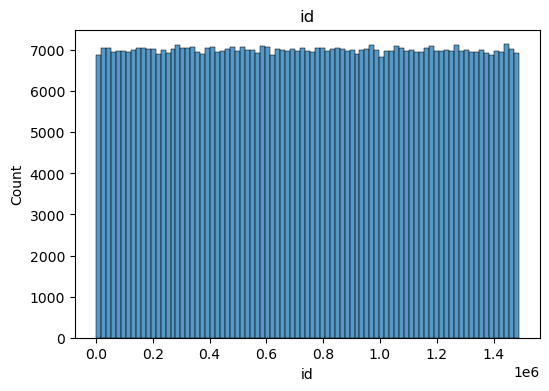

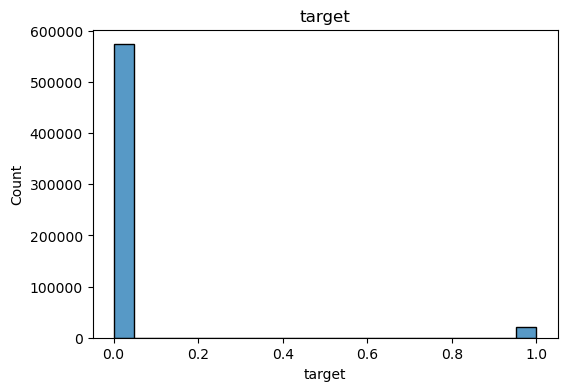

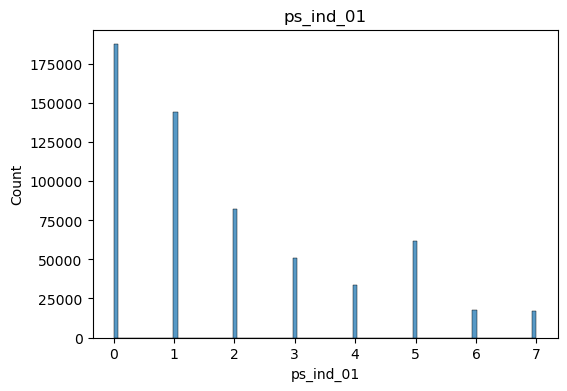

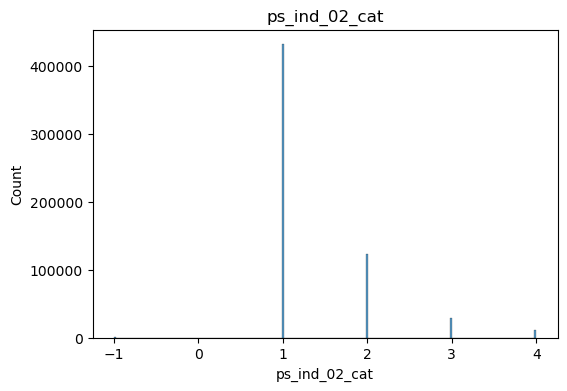

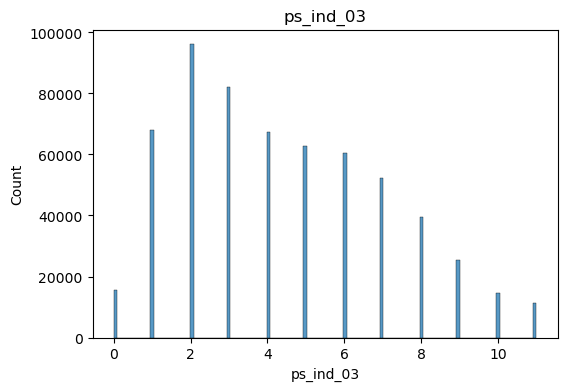

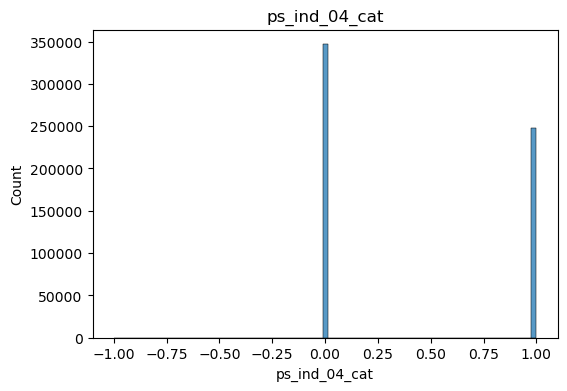

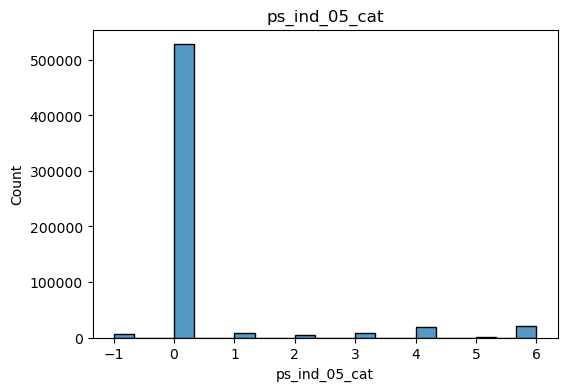

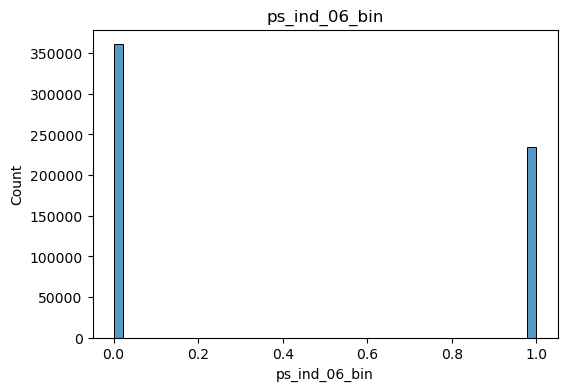

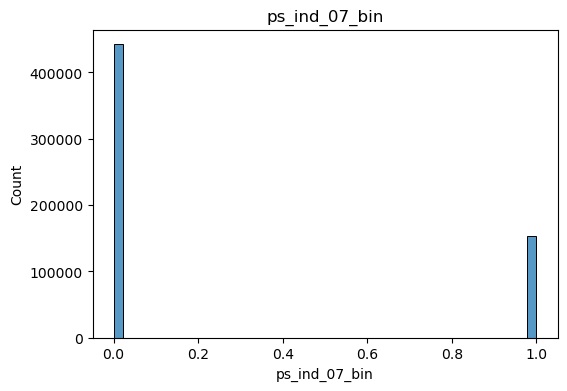

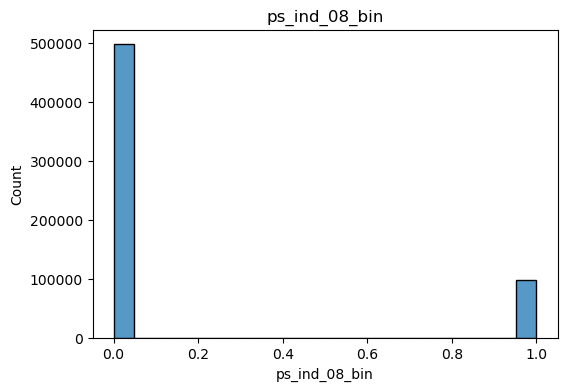

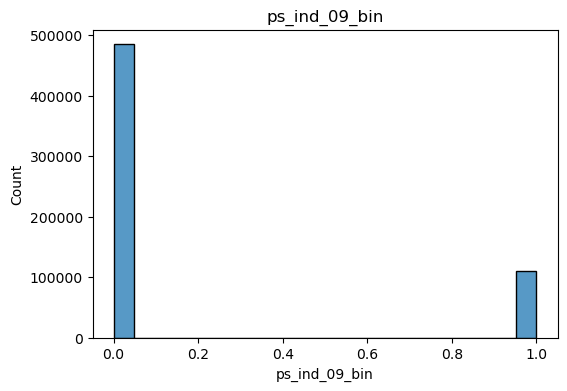

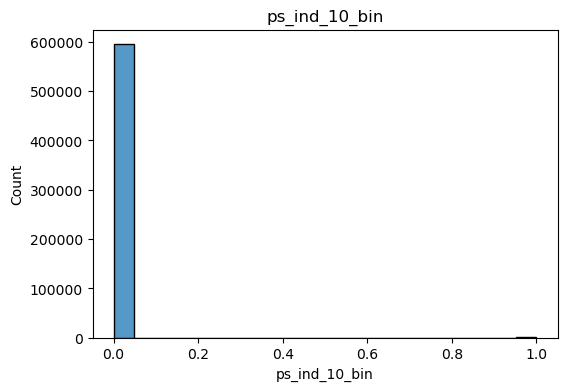

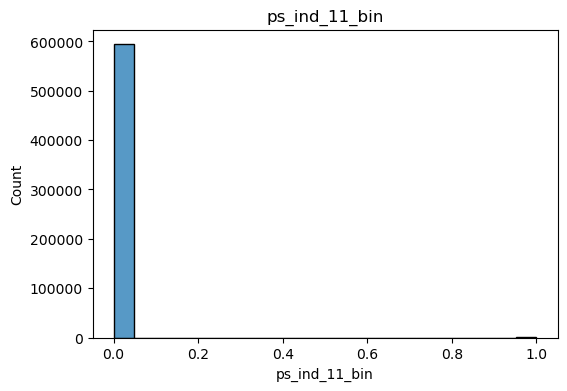

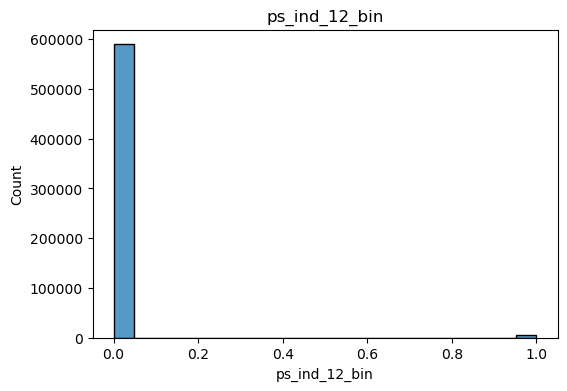

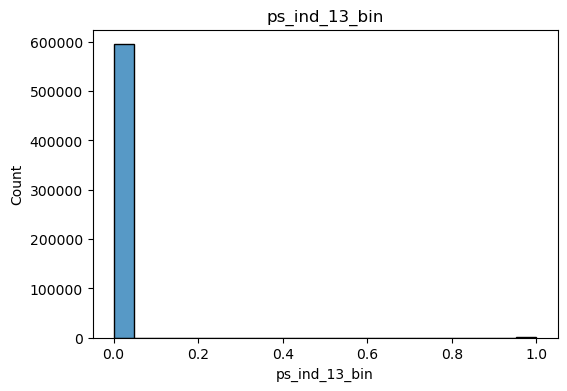

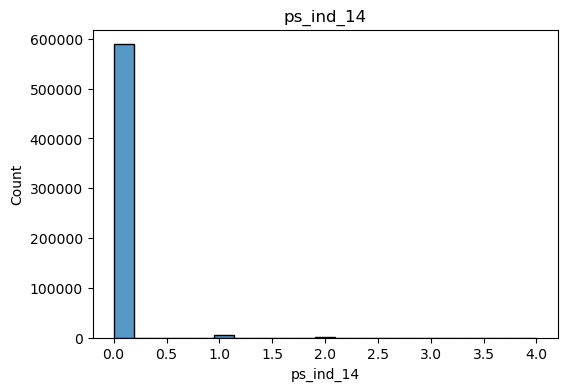

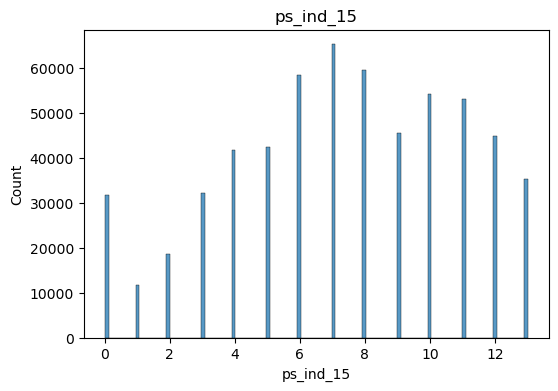

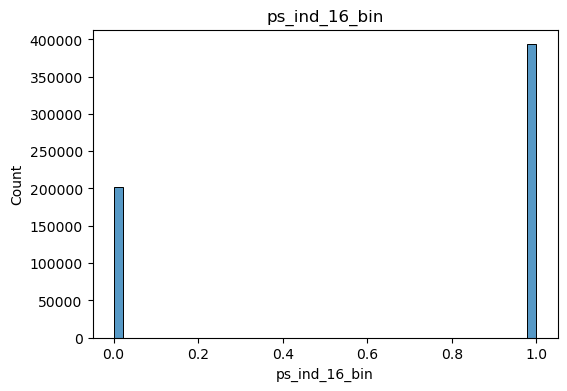

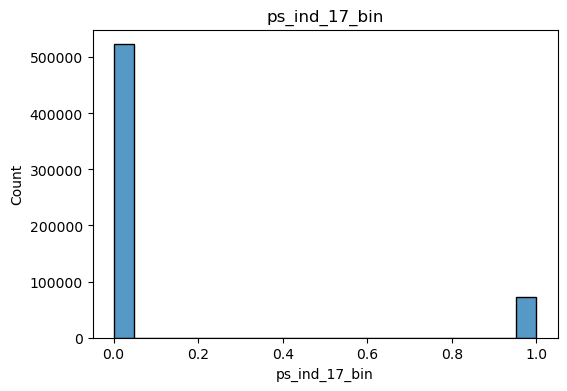

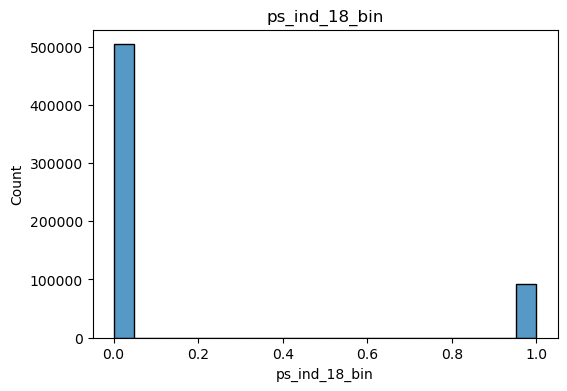

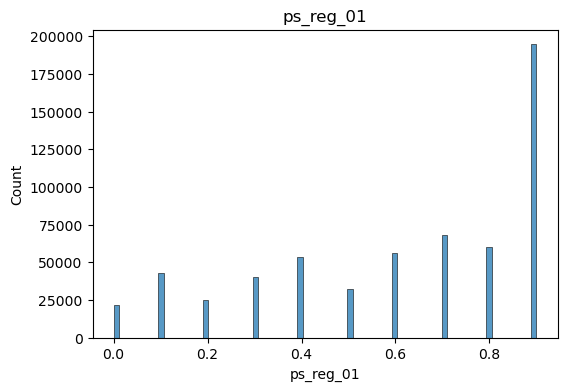

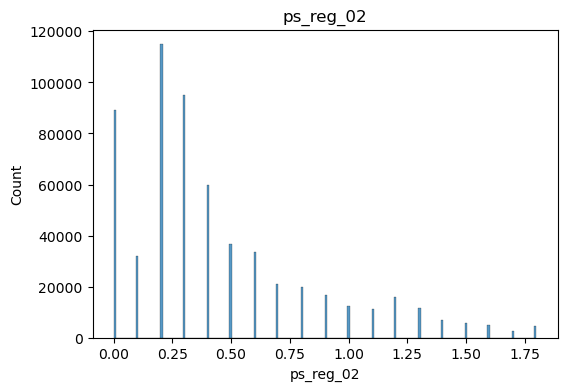

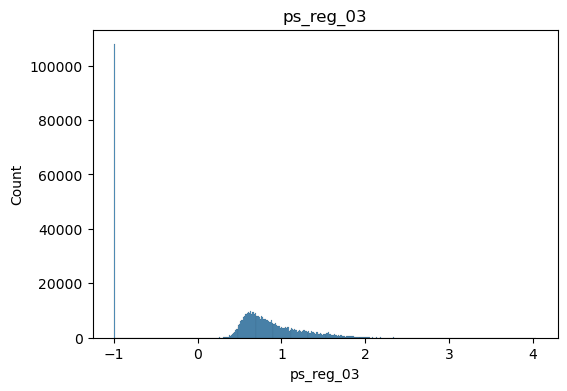

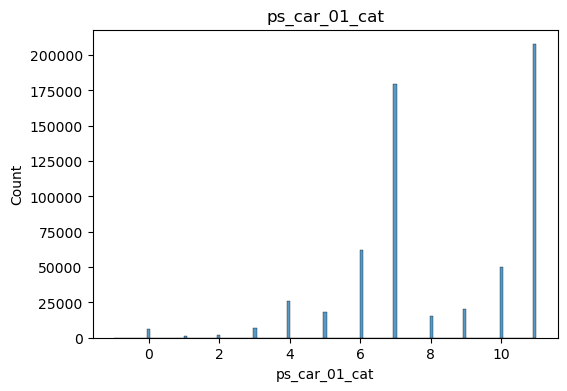

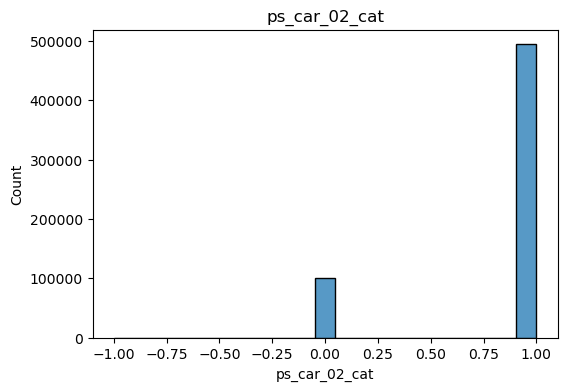

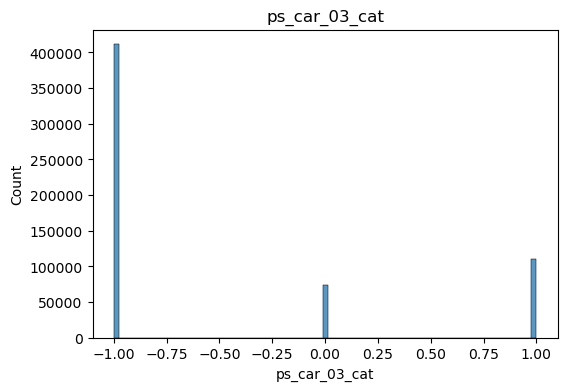

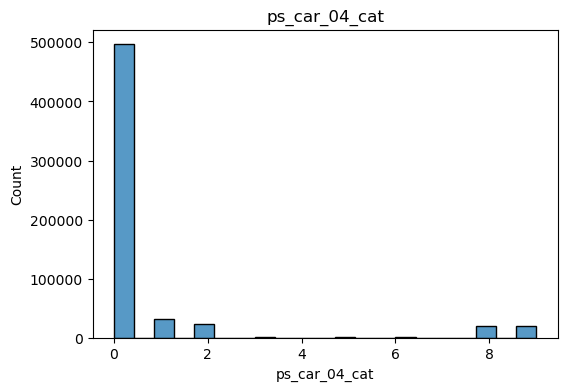

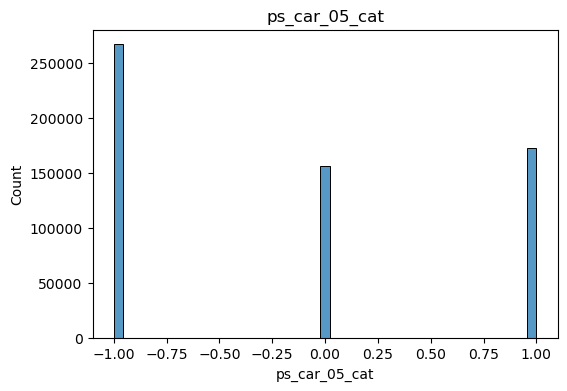

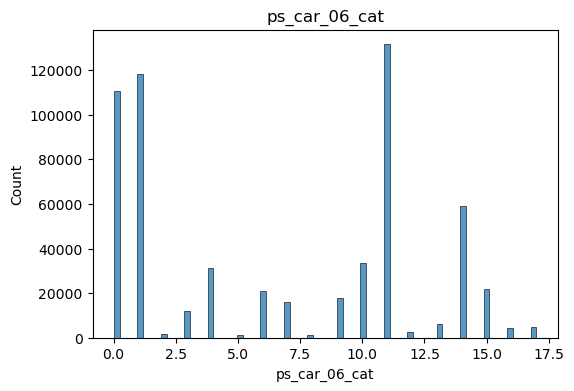

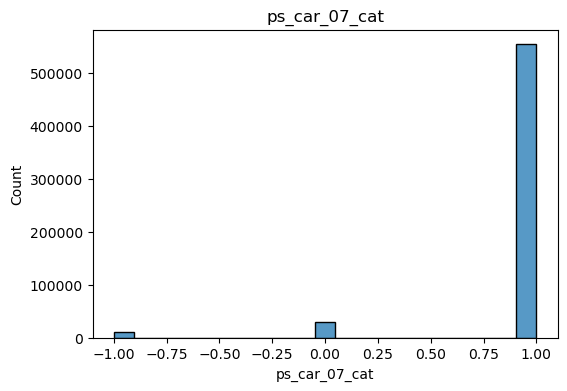

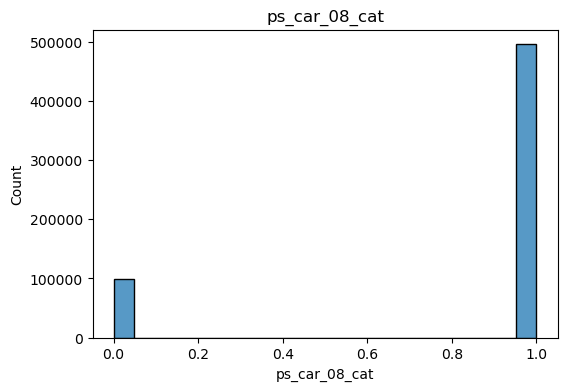

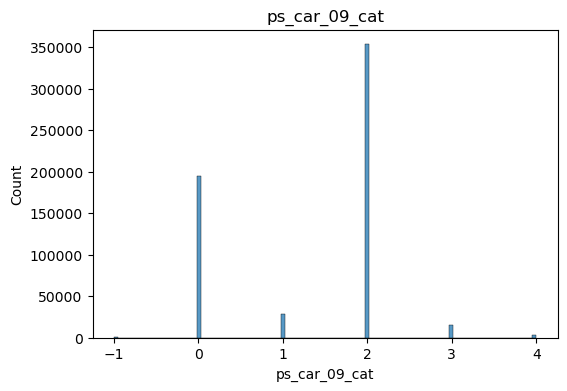

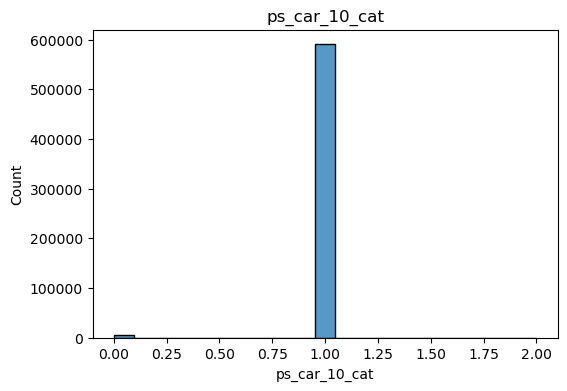

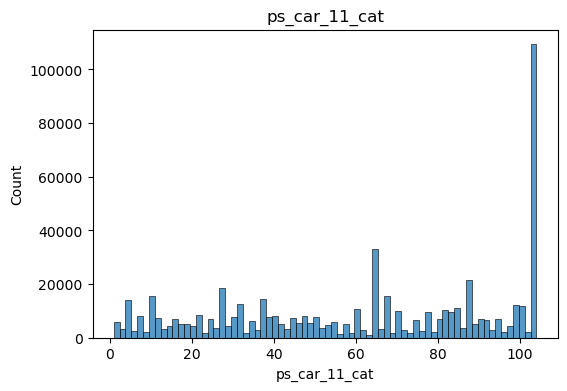

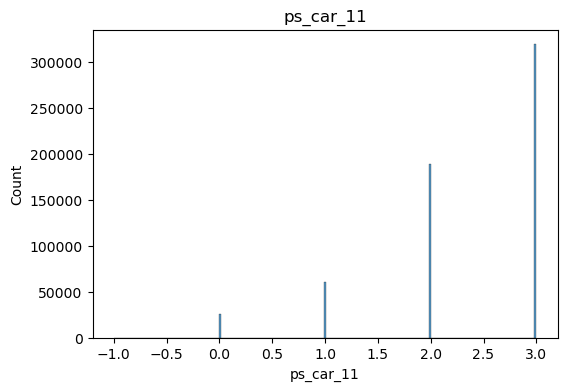

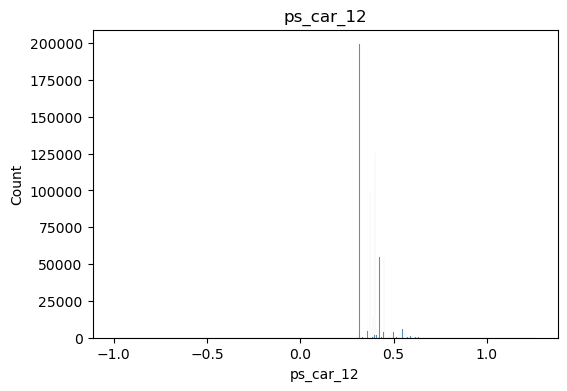

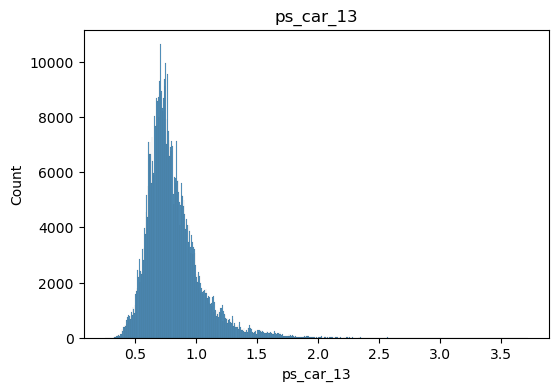

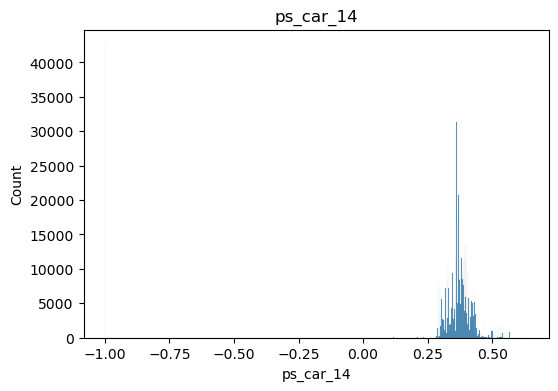

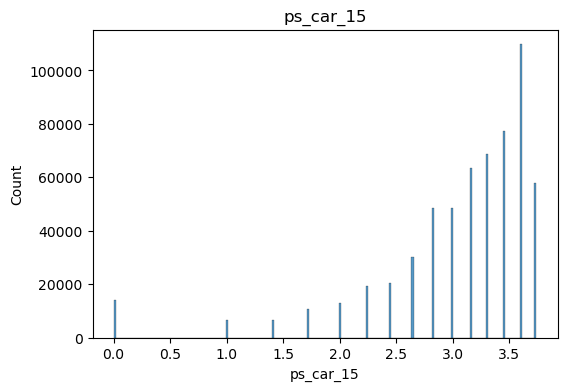

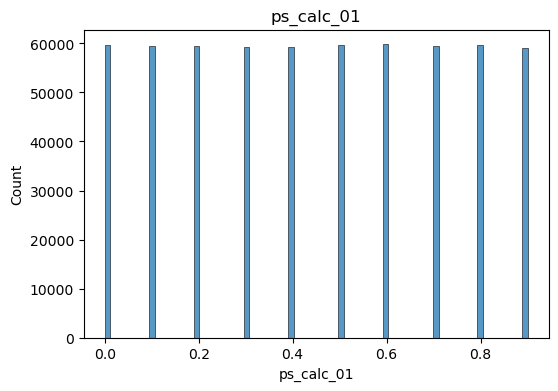

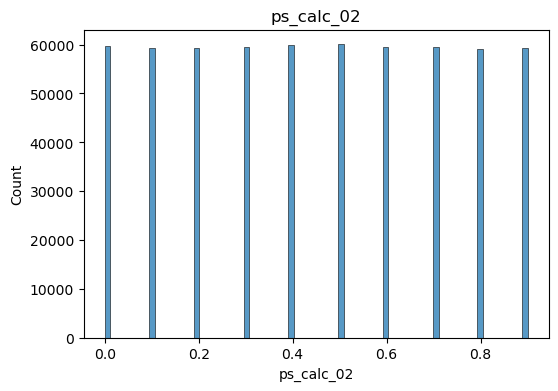

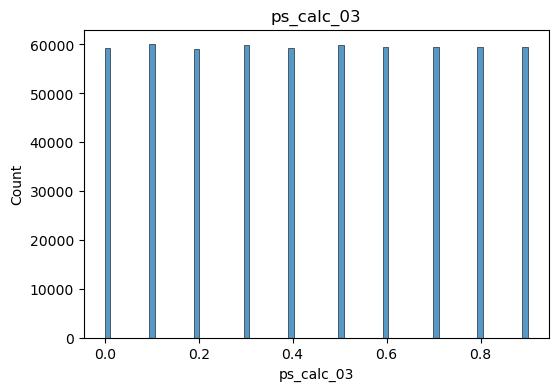

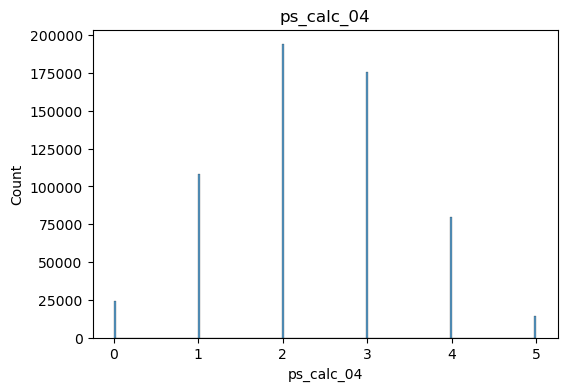

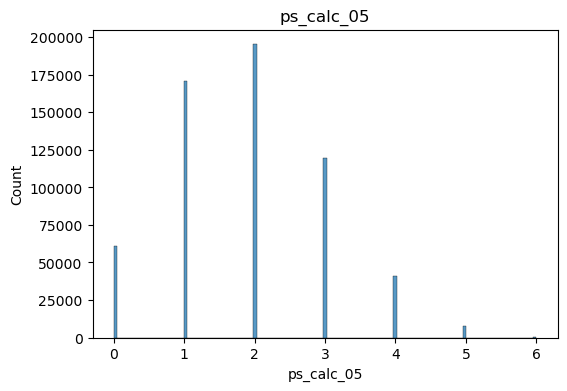

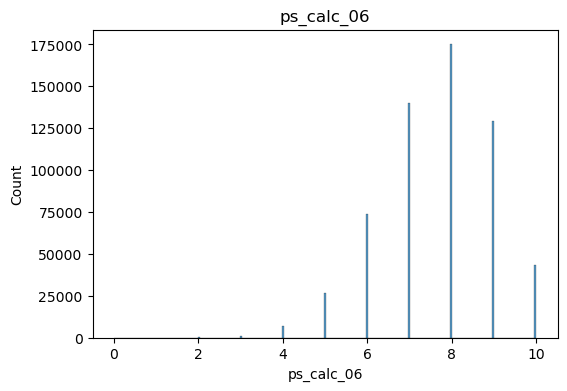

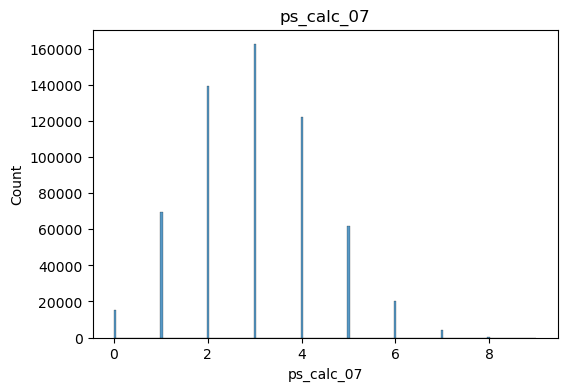

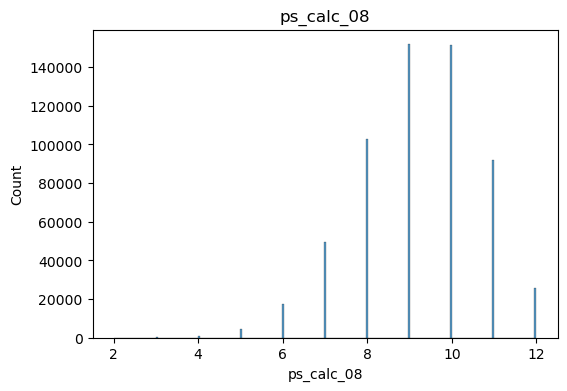

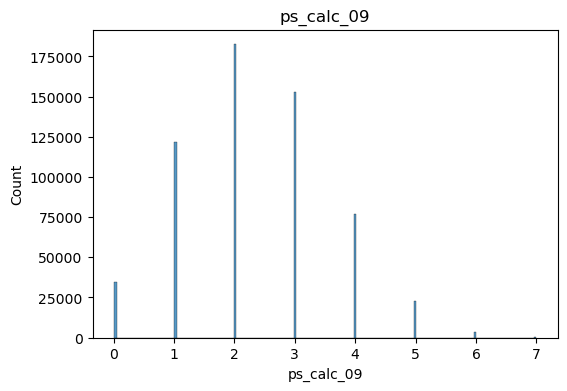

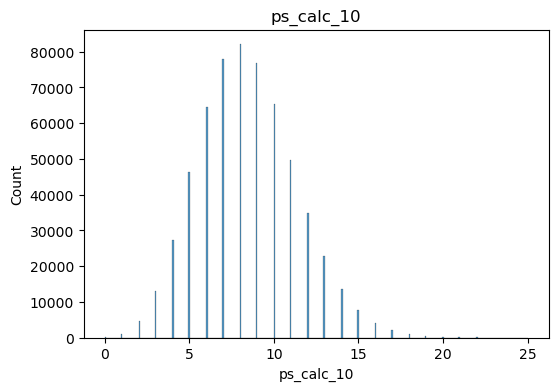

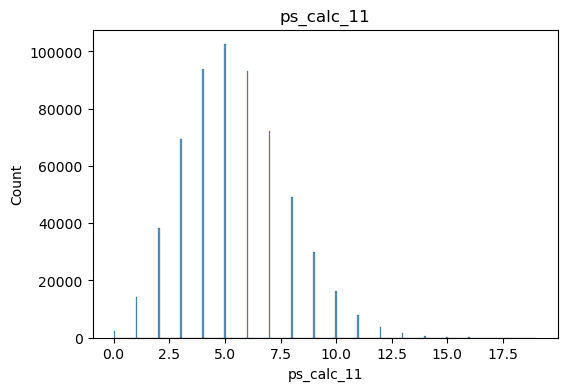

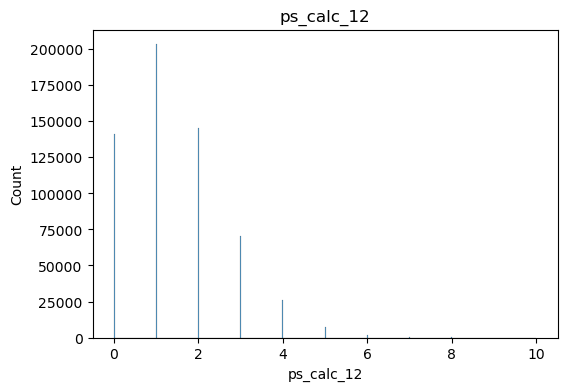

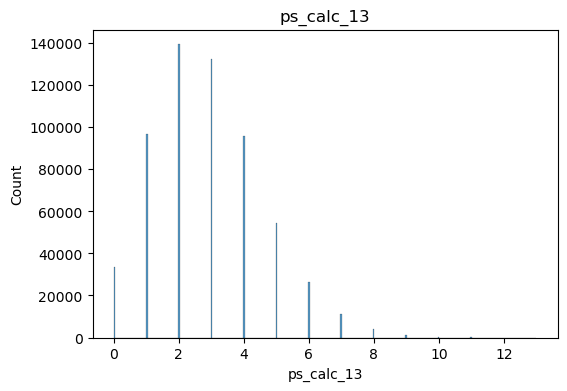

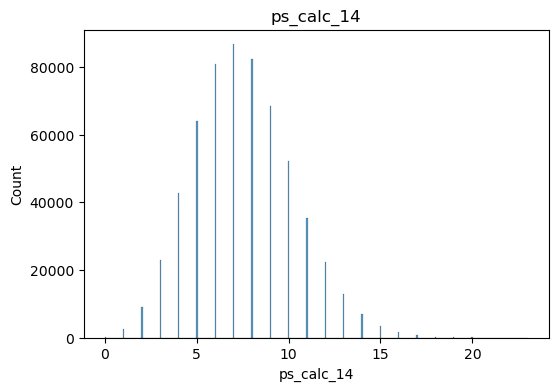

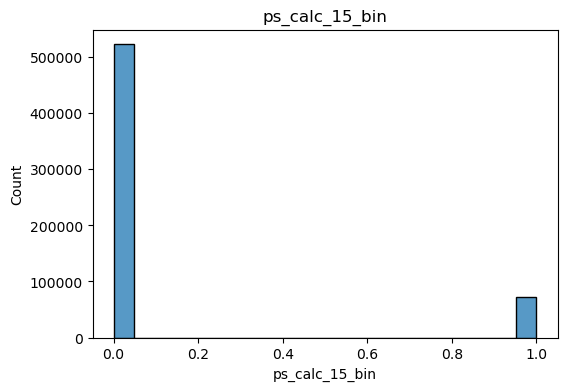

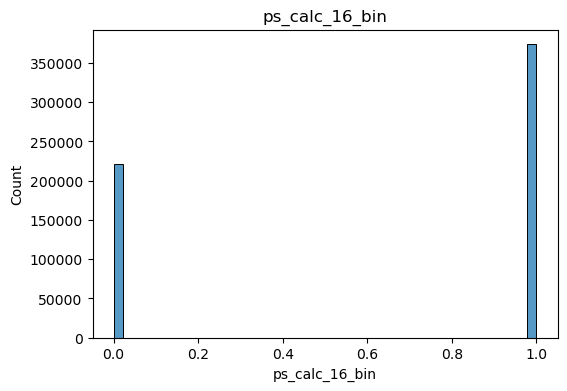

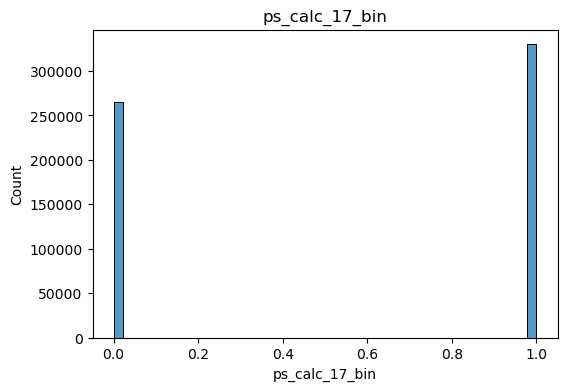

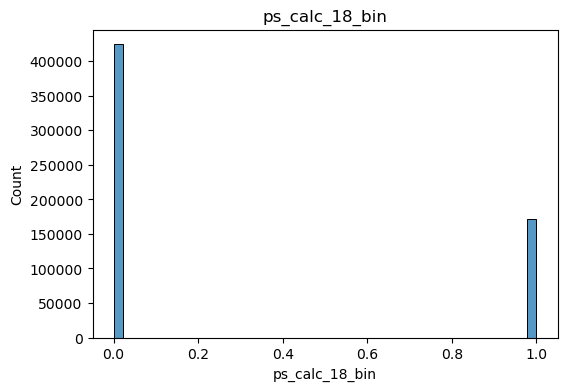

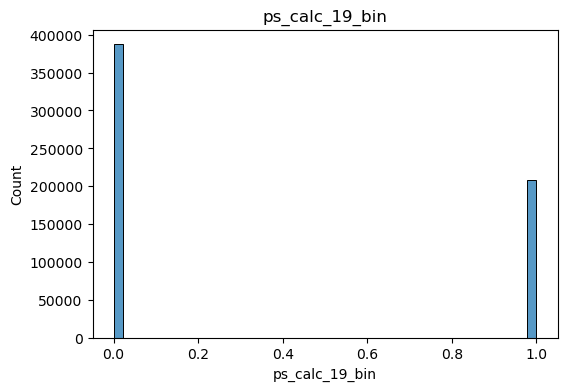

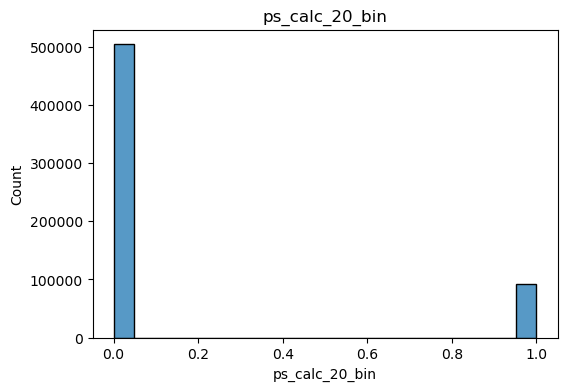

In [15]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col])
    plt.title(col)
    plt.show()

### Enhance outlier analysis

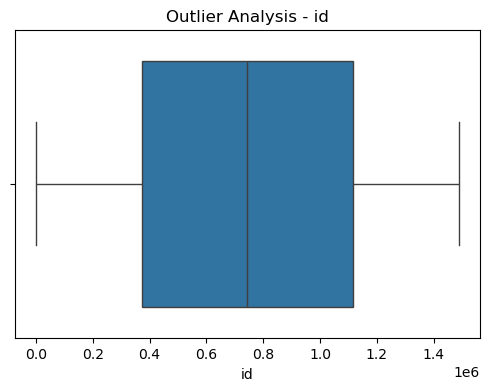

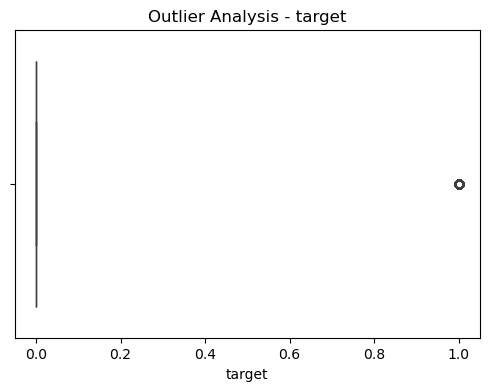

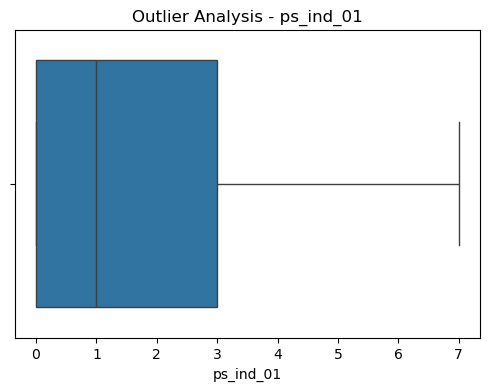

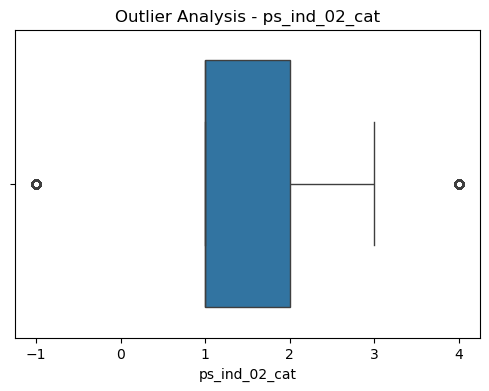

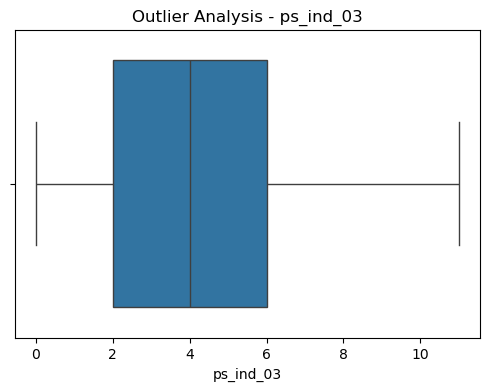

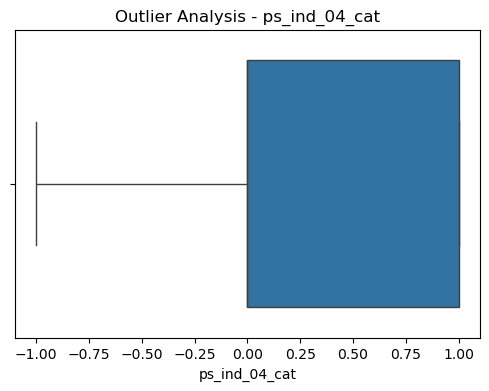

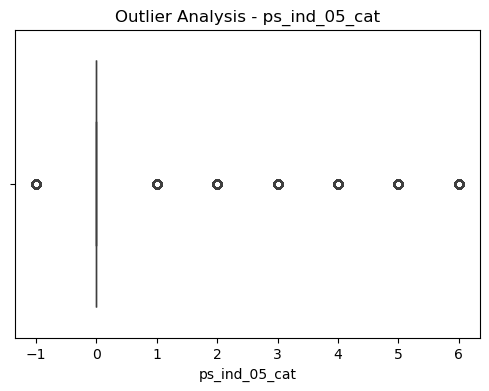

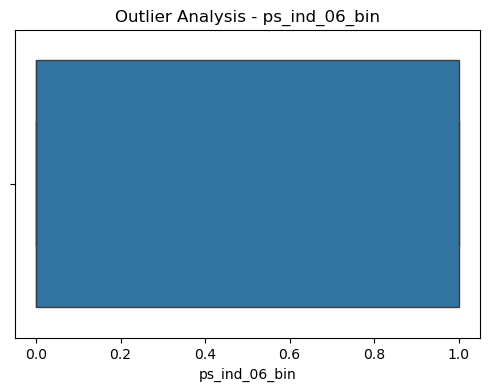

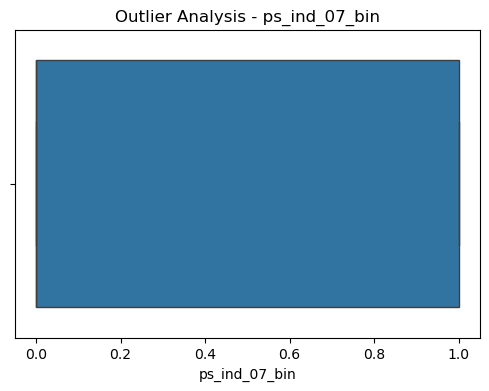

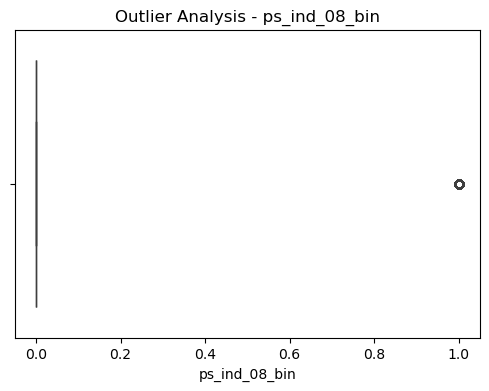

In [16]:
for col in num_cols[:10]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Analysis - {col}")
    plt.show()

Observations:
- Several numerical features contain extreme values
- Outlier presence supports the use of ensemble and boosting models

Implication:
- Tree-based algorithms are preferred due to their robustness against outliers

### Correlation with Target

In [17]:
corr = df.corr()

target_corr = corr['target'].sort_values(ascending=False)
target_corr.head(10)

target           1.000000
ps_car_13        0.053899
ps_car_12        0.038790
ps_ind_17_bin    0.037053
ps_reg_02        0.034800
ps_ind_07_bin    0.034218
ps_car_04_cat    0.032900
ps_car_03_cat    0.032401
ps_reg_03        0.030888
ps_ind_05_cat    0.029165
Name: target, dtype: float64

Observations:
- Some features show strong correlation with the target variable
- These features are important predictors

Implication:
- Useful for feature selection and model building

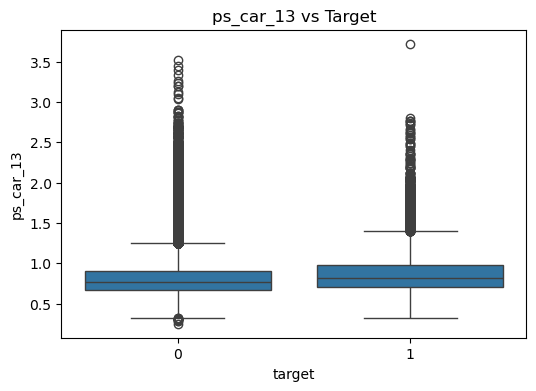

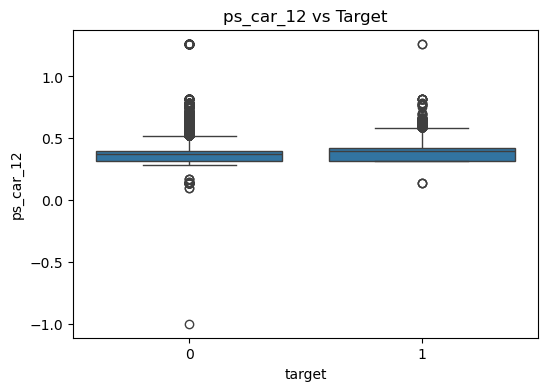

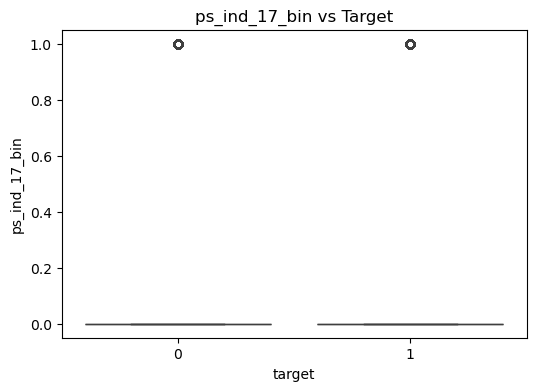

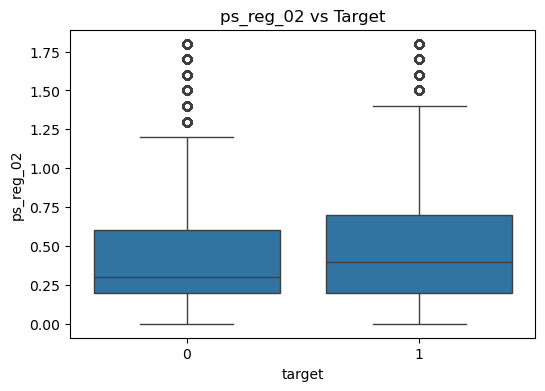

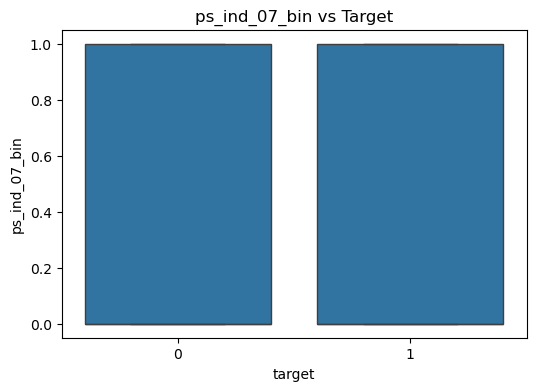

In [18]:
top_features = target_corr.index[1:6]

for col in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

Observations:
- Some features show clear separation between classes
- Indicates strong predictive power

Implication:
- These features help the model distinguish between buyers and non-buyers

### Target-wise Distribution Comparison 

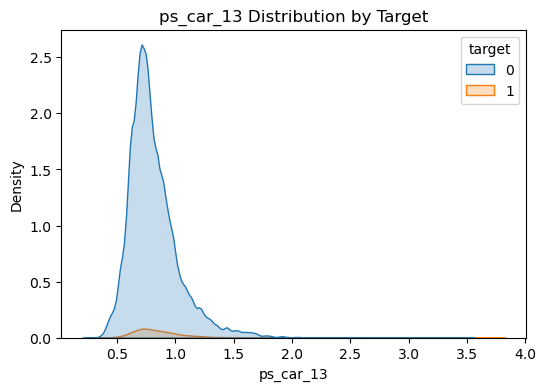

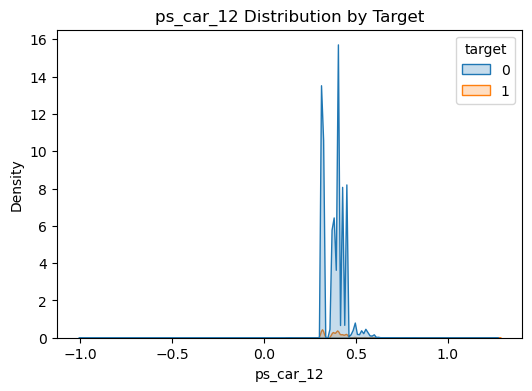

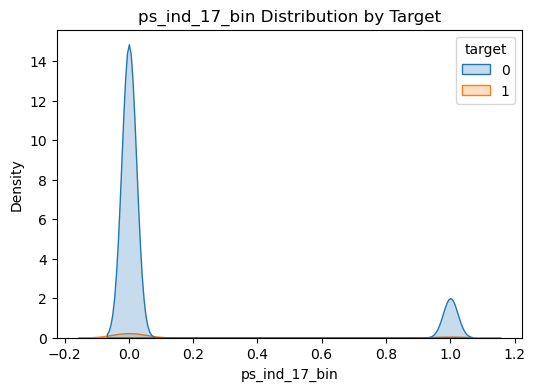

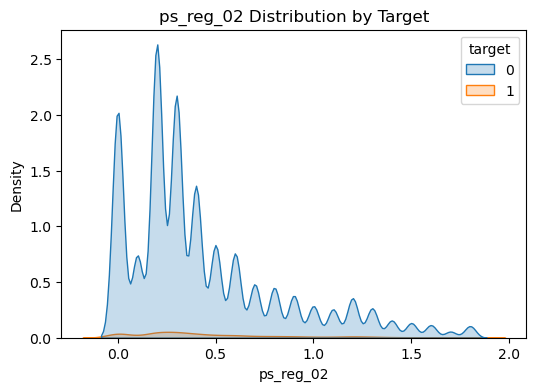

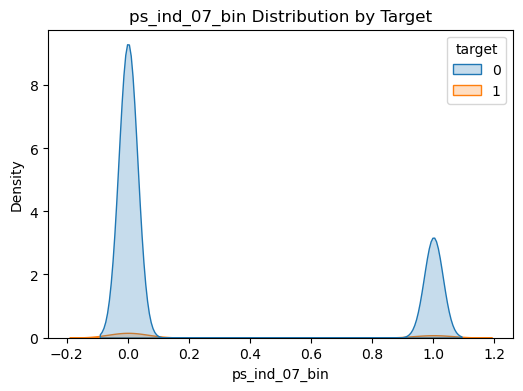

In [19]:
for col in top_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue='target', fill=True)
    plt.title(f"{col} Distribution by Target")
    plt.show()

Observations:
- Features with less overlap between classes are better predictors
- Features with high overlap have low predictive power

Implication:
- Helps in selecting relevant features

### The data is already Preprocessed (encoded & scaled) but not Balanced 

### Feature & Target Split

In [20]:
X = df.drop('target', axis=1)
y = df['target']

splitting the data into input feature and target

### Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Splits the dataset into training (80%) and testing (20%) sets.

### Balancing Data

In [22]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

The dataset was highly imbalanced, which could bias models toward the majority class. SMOTE and class weighting techniques were used to improve minority class prediction performance.

### Model Training

### Logistic Regression

In [23]:
lr = LogisticRegression()
lr.fit(X_train_res, y_train_res)

LogisticRegression()

In [24]:
lr_y_pred = lr.predict(X_test)
lr_y_pred

array([0, 0, 0, ..., 0, 0, 1])

### Logistic Regression Evalution

In [25]:
print("Confusion Matrix of LR:\n", confusion_matrix(y_test, lr_y_pred))
print("Accuracy of LR:", accuracy_score(y_test, lr_y_pred))
print("Precision of LR:", precision_score(y_test, lr_y_pred))
print("Recall of LR:", recall_score(y_test, lr_y_pred))
print("F1 Score of LR:", f1_score(y_test, lr_y_pred))
print("ROC-AUC of LR:", roc_auc_score(y_test, lr_y_pred))

Confusion Matrix of LR:
 [[76482 38176]
 [ 2591  1794]]
Accuracy of LR: 0.657543912703813
Precision of LR: 0.04488366274706029
Recall of LR: 0.4091220068415051
F1 Score of LR: 0.08089279675346635
ROC-AUC of LR: 0.5380833045249058


### Decision Tree

In [26]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)

DecisionTreeClassifier(random_state=42)

In [27]:
dt_y_pred = dt.predict(X_test)
dt_y_pred

array([0, 0, 0, ..., 0, 0, 0])

### Decision Tree Evalution

In [28]:
print("Confusion Matrix of DT:\n", confusion_matrix(y_test, dt_y_pred))
print("Accuracy of DT:", accuracy_score(y_test,dt_y_pred))
print("Precision of DT:", precision_score(y_test,dt_y_pred))
print("Recall of DT:", recall_score(y_test, dt_y_pred))
print("F1 Score of DT:", f1_score(y_test, dt_y_pred))
print("ROC-AUC of DT:", roc_auc_score(y_test, dt_y_pred))

Confusion Matrix of DT:
 [[108020   6638]
 [  4058    327]]
Accuracy of DT: 0.9101501138244164
Precision of DT: 0.04694903086862886
Recall of DT: 0.07457240592930445
F1 Score of DT: 0.05762114537444934
ROC-AUC of DT: 0.5083392476715196


### Random Forest

In [29]:
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=50, random_state=42)

In [30]:
rf_y_pred = rf.predict(X_test)
rf_y_pred

array([0, 0, 0, ..., 0, 0, 0])

### Random Forest Evalution

In [31]:
print("Confusion Matrix of RF:\n", confusion_matrix(y_test, rf_y_pred))
print("Accuracy of RF:", accuracy_score(y_test,rf_y_pred))
print("Precision of RF:", precision_score(y_test,rf_y_pred))
print("Recall of RF:", recall_score(y_test, rf_y_pred))
print("F1 Score of RF:", f1_score(y_test, rf_y_pred))
print("ROC-AUC of RF:", roc_auc_score(y_test, rf_y_pred))

Confusion Matrix of RF:
 [[114593     65]
 [  4380      5]]
Accuracy of RF: 0.9626605512293877
Precision of RF: 0.07142857142857142
Recall of RF: 0.0011402508551881414
F1 Score of RF: 0.002244668911335578
ROC-AUC of RF: 0.5002866737713642


### XGB

In [32]:
xgb = XGBClassifier(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [33]:
xgb_y_pred = xgb.predict(X_test)
xgb_y_pred

array([0, 0, 0, ..., 0, 0, 0])

### XGB Evalution

In [34]:
print("Confusion Matrix of XGB:\n", confusion_matrix(y_test, xgb_y_pred))
print("Accuracy of XGB:", accuracy_score(y_test,xgb_y_pred))
print("Precision of XGB:", precision_score(y_test,xgb_y_pred))
print("Recall of XGB:", recall_score(y_test, xgb_y_pred))
print("F1 Score of XGB:", f1_score(y_test, xgb_y_pred))
print("ROC-AUC of XGB:", roc_auc_score(y_test, xgb_y_pred))

Confusion Matrix of XGB:
 [[114071    587]
 [  4352     33]]
Accuracy of XGB: 0.9585107902186605
Precision of XGB: 0.0532258064516129
Recall of XGB: 0.007525655644241733
F1 Score of XGB: 0.013186813186813187
ROC-AUC of XGB: 0.50120304132663


### Hyperparameter Tuning

### HT_LR

In [35]:
from sklearn.model_selection import GridSearchCV

param_lr = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=100),
    param_lr,
    cv=3,
    n_jobs=-1
)

grid_lr.fit(X_train_res, y_train_res)

best_lr = grid_lr.best_estimator_

In [36]:
hlr_y_pred = grid_lr.predict(X_test)
hlr_y_pred

array([0, 0, 0, ..., 0, 0, 1])

### HT_LR Evalution

In [37]:
print("Confusion Matrix of HT_LR:\n", confusion_matrix(y_test, hlr_y_pred))
print("Accuracy of HT_LR:", accuracy_score(y_test, hlr_y_pred))
print("Precision of HT_LR:", precision_score(y_test, hlr_y_pred))
print("Recall of HT_LR:", recall_score(y_test, hlr_y_pred))
print("F1 Score of HT_LR:", f1_score(y_test, hlr_y_pred))
print("ROC-AUC of HT_LR:", roc_auc_score(y_test, hlr_y_pred))

Confusion Matrix of HT_LR:
 [[76465 38193]
 [ 2590  1795]]
Accuracy of HT_LR: 0.6574095074888906
Precision of HT_LR: 0.04488846653996199
Recall of HT_LR: 0.40935005701254273
F1 Score of HT_LR: 0.08090505487571271
ROC-AUC of HT_LR: 0.5381231961003338


### HT_DT

In [38]:
param_dt = {
    'max_depth': [5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=3,
    n_jobs=-1
)

grid_dt.fit(X_train_res, y_train_res)

best_dt = grid_dt.best_estimator_

In [39]:
hdt_y_pred = grid_dt.predict(X_test)
hdt_y_pred

array([0, 0, 0, ..., 0, 0, 0])

### HT_DT Evalution

In [40]:
print("Confusion Matrix of HT_DT:\n", confusion_matrix(y_test, hdt_y_pred))
print("Accuracy of HT_DT:", accuracy_score(y_test,hdt_y_pred))
print("Precision of HT_DT:", precision_score(y_test,hdt_y_pred))
print("Recall of HT_DT:", recall_score(y_test, hdt_y_pred))
print("F1 Score of HT_DT:", f1_score(y_test, hdt_y_pred))
print("ROC-AUC of HT_DT:", roc_auc_score(y_test, hdt_y_pred))

Confusion Matrix of HT_DT:
 [[111460   3198]
 [  4258    127]]
Accuracy of HT_DT: 0.9373671698461901
Precision of HT_DT: 0.03819548872180451
Recall of HT_DT: 0.02896237172177879
F1 Score of HT_DT: 0.032944228274967575
ROC-AUC of HT_DT: 0.5005353643743817


### HT_RF

In [41]:
param_rf = {
    'n_estimators': [50, 80],
    'max_depth': [4,6],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train_res, y_train_res)

best_rf = grid_rf.best_estimator_

In [42]:
hrf_y_pred = grid_rf.predict(X_test)
hrf_y_pred

array([0, 0, 0, ..., 0, 0, 0])

### HT_RF Evalution

In [43]:
print("Confusion Matrix HT_RF:\n", confusion_matrix(y_test, hrf_y_pred))
print("Accuracy HT_RF:", accuracy_score(y_test,hrf_y_pred))
print("Precision HT_RF:", precision_score(y_test,hrf_y_pred))
print("Recall HT_RF:", recall_score(y_test, hrf_y_pred))
print("F1 Score HT_RF:", f1_score(y_test, hrf_y_pred))
print("ROC-AUC HT_RF:", roc_auc_score(y_test, hrf_y_pred))

Confusion Matrix HT_RF:
 [[108005   6653]
 [  3951    434]]
Accuracy HT_RF: 0.9109229438102199
Precision HT_RF: 0.06123888810498095
Recall HT_RF: 0.09897377423033067
F1 Score HT_RF: 0.07566248256624826
ROC-AUC HT_RF: 0.5204745199013643


### HT_XGB

In [44]:
from xgboost import XGBClassifier

param_xgb = {
    'n_estimators': [60, 80],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 1],
    'reg_lambda': [1, 5]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_xgb,
    cv=3,
    n_jobs=-1
)

grid_xgb.fit(X_train_res, y_train_res)

best_xgb = grid_xgb.best_estimator_

In [45]:
hxgb_y_pred = grid_xgb.predict(X_test)
hxgb_y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [46]:
print("Confusion Matrix of HT_XGB:\n", confusion_matrix(y_test, hxgb_y_pred))
print("Accuracy of HT_XGB:", accuracy_score(y_test,hxgb_y_pred))
print("Precision of HT_XGB:", precision_score(y_test,hxgb_y_pred))
print("Recall of HT_XGB:", recall_score(y_test, hxgb_y_pred))
print("F1 Score of HT_XGB:", f1_score(y_test, hxgb_y_pred))
print("ROC-AUC of HT_XGB:", roc_auc_score(y_test, hxgb_y_pred))

Confusion Matrix of HT_XGB:
 [[114614     44]
 [  4382      3]]
Accuracy of HT_XGB: 0.962820157422108
Precision of HT_XGB: 0.06382978723404255
Recall of HT_XGB: 0.0006841505131128849
F1 Score of HT_XGB: 0.0013537906137184115
ROC-AUC of HT_XGB: 0.5001502002892625


### Model Comperision

In [47]:
models = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGB"],
    "Accuracy Score": [
        accuracy_score(y_test, lr_y_pred),
        accuracy_score(y_test, dt_y_pred),
        accuracy_score(y_test, rf_y_pred),
        accuracy_score(y_test, xgb_y_pred),]
    ,
    "Hp_Tuned_Model": [
        accuracy_score(y_test, hlr_y_pred),
        accuracy_score(y_test, hdt_y_pred),
        accuracy_score(y_test, hrf_y_pred),
        accuracy_score(y_test, hxgb_y_pred),]
})
models

,Model,Accuracy Score,Hp_Tuned_Model
0,Logistic Regression,0.657544,0.657410
1,Decision Tree,0.910150,0.937367
2,Random Forest,0.962661,0.910923
3,XGB,0.958511,0.962820


Accuracy of tuned XGB is Highest(0.963139) amongst all so XGB is best

### Business Insights

### Save and load the Model

In [48]:
import pickle

# Save model
with open('best_xgb.pkl', 'wb') as file:
    pickle.dump(best_xgb, file)

In [49]:
# Load model
with open('best_xgb.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

y_pred = loaded_model.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 0]


- Model identifies high probability customers
- Certain features strongly influence purchase decisions
- Helps reduce marketing cost by targeting relevant users

### Marketing Recommendations

1. Target customers with high predicted probability
2. Use personalized campaigns (email, SMS)
3. Segment customers into high/medium/low groups
4. Focus on digital marketing channels
5. Apply cross-selling strategies

### Challenges Faced

1. Imbalanced Dataset
   - The dataset contained very few positive samples compared to negative samples.
   - Addressed using SMOTE, class weighting, and threshold tuning.

2. Large Dataset Size
   - Training and tuning models on 595K+ records increased computational cost.
   - Smaller parameter grids and efficient algorithms were used.

3. Anonymous Features
   - Feature names were anonymized due to privacy concerns.
   - Statistical EDA and feature importance methods were used instead of domain interpretation.

4. Outliers and Skewed Data
   - Several features contained outliers and skewed distributions.
   - Robust ensemble and boosting algorithms were selected.

5. Low Initial F1 Scores
   - Initial models struggled due to severe class imbalance.
   - Improved using hyperparameter tuning, scale_pos_weight, and threshold optimization.s.

### Conclusion

This project successfully developed a machine learning solution to predict customer insurance purchase behavior using a large and highly imbalanced dataset.

Comprehensive EDA, preprocessing, and model evaluation techniques were applied to understand data patterns and improve model performance. Multiple machine learning models were trained and compared, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost.

Among all models, Tuned XGBoost achieved the best performance due to its strong Recall, F1 Score, and ability to handle imbalanced data effectively. The project demonstrates how machine learning can support data-driven marketing strategies by identifying high-potential customers and improving campaign efficiency.

Future improvements may include:
- Advanced feature engineering
- PCA or dimensionality reduction
- LightGBM or CatBoost implementation
- Deep learning approaches
- Real-time deployment and monitorings.